In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import itertools
from tqdm import tqdm
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

#from pangal.pfitter import PFitter
from pangal.photometry_table import PhotometryTable

from pangal.spectrum import Spectrum
from pangal.pfitter import PFitter
from pangal.npfitter import NPFitter
from pangal.run import Run

import warnings
warnings.simplefilter("ignore")

import fsps
from astropy.io import fits

from pangal.model_builders.simple_fsps import make_ssp_with_fsps


In [2]:
bins=np.logspace(1,np.log10(13000),1000)
spec = make_ssp_with_fsps(ages=bins,filename='FSPS_SSPs')

100%|██████████████████████████████████████| 1000/1000 [00:02<00:00, 389.08it/s]


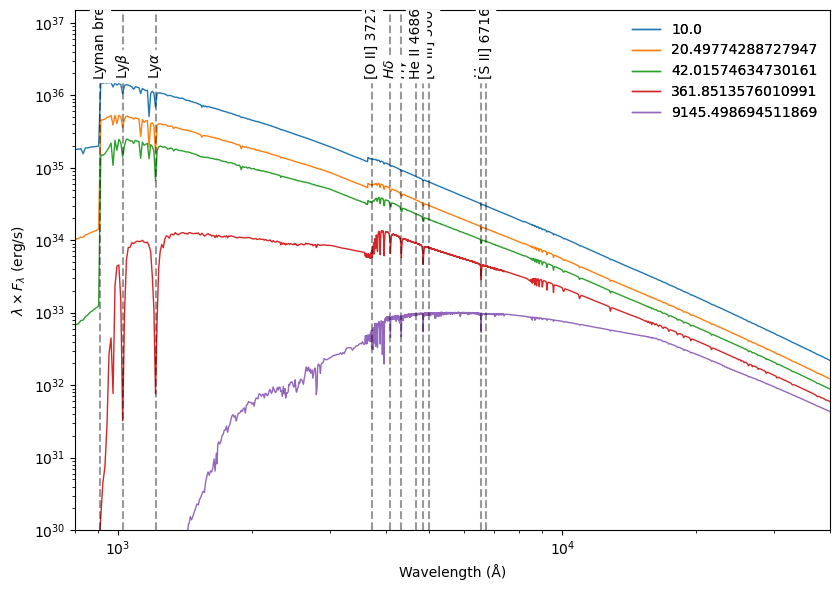

In [3]:

Spectrum().plot(spectra=[spec[0],spec[100],spec[200],spec[500],spec[950]],
        show_top_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 800,
        wsup=4e4,
        spec_legend_pars='age',
        #zoom_on_line=['Ha','Hd'],
        #remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(10,6),
        redshift=0,
        ymin=1e30,
        spec_legend_loc='upper right',
)


Line Ha EW: 0.23 Å
Line [N II] 6548 EW: 0.01 Å
Line [N II] 6583 EW: 0.04 Å
Line Ha EW: 0.46 Å
Line [N II] 6548 EW: 0.02 Å
Line [N II] 6583 EW: 0.08 Å
Line Ha EW: 0.70 Å
Line [N II] 6548 EW: 0.04 Å
Line [N II] 6583 EW: 0.11 Å
Line Ha EW: 2.82 Å
Line [N II] 6548 EW: 0.32 Å
Line [N II] 6583 EW: 0.52 Å
Line Ha EW: 2.41 Å
Line [N II] 6548 EW: 0.12 Å
Line [N II] 6583 EW: 0.11 Å
Line Ha EW: 2.30 Å
Line [N II] 6548 EW: 0.12 Å
Line [N II] 6583 EW: 0.10 Å
Line Hd EW: 0.20 Å
Line Hd EW: 0.45 Å
Line Hd EW: 0.69 Å
Line Hd EW: 4.46 Å
Line Hd EW: 3.30 Å
Line Hd EW: 3.14 Å


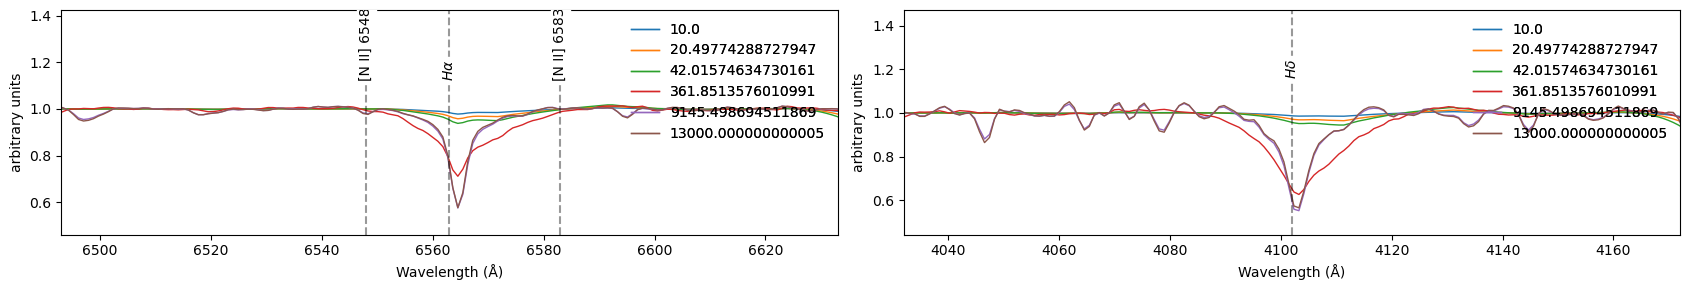

In [4]:
Spectrum().plot(spectra=[spec[0],spec[100],spec[200],spec[500],spec[950],spec[999]],
        show_all_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 800,
        wsup=1e6,
        spec_legend_pars='age',
        zoom_on_line=['Ha','Hd'],
        equivalent_widths=True,
        ew_window=10,
        remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(20,3),
        redshift=0,
        spec_legend_loc='upper right',
)



Line Hb EW: 0.17 Å
Line Hb EW: 0.37 Å
Line Hb EW: 0.54 Å
Line Hb EW: 3.49 Å
Line Hb EW: 2.41 Å
Line Hb EW: 2.17 Å


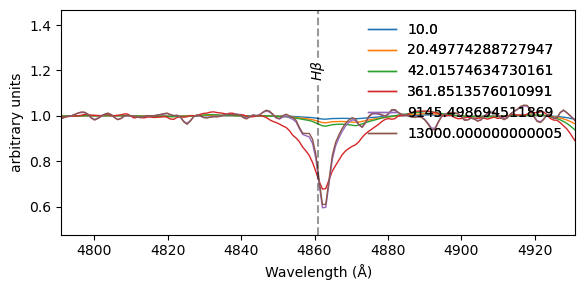

In [5]:
Spectrum().plot(spectra=[spec[0],spec[100],spec[200],spec[500],spec[950],spec[999]],
        show_all_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 800,
        wsup=1e6,
        spec_legend_pars='age',
        zoom_on_line=['Hb'],
        equivalent_widths=True,
        ew_window=10,
        remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(7,3),
        redshift=0,
        spec_legend_loc='upper right',
)

In [2]:
npfitter = NPFitter(model_file='FSPS_SSPs')


Initializing NPFitter object
Loading SSPs SEDs from  FSPS_SSPs
Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 3.1875 3.25   3.3125 3.375  3.4375 3.5    3.5625 3.625  3.6875 3.75
 3.8125 3.875  3.9375 4.    ]
Loading of dust emission templates completed.


In [3]:
# Time bins in Myr (lookback)
time_bins = np.array([9, 50, 100, 300, 500, 1000, 5000, 10000])  # Myr
# Convert to Gyr for plotting 
time_bins_gyr = time_bins / 1000

In [4]:

# Normal galaxy: moderate, roughly continuous SF
# Smooth SF over cosmic time
sfh_normal = np.array([2, 3, 4, 5, 5, 4, 3, 2])

# Starburst galaxy: recent burst dominates
# High SF in youngest bins, low SF in older bins
sfh_starburst = np.array([10, 8, 4, 2, 1, 1, 0.5, 0.5])

# Post-starburst: burst a bit earlier, now quenching
# Strong SF in young-intermediate bins, negligible now
sfh_poststarburst = np.array([1, 2, 5, 4, 1, 0.5, 0.1, 0.0])

# Quiescent galaxy: mostly old stars, negligible recent SF
# Peak SF in oldest bins, tiny in youngest
sfh_quiescent = np.array([0.1, 0.2, 0.5, 1, 2, 3, 5, 10])

In [5]:
# Normalize for plotting

sfh_normal_n = sfh_normal / 1#np.sum(sfh_normal)
sfh_starburst_n = sfh_starburst / 1#np.sum(sfh_starburst)
sfh_poststarburst_n = sfh_poststarburst / 1#np.sum(sfh_poststarburst)
sfh_quiescent_n = sfh_quiescent / 1#np.sum(sfh_quiescent)

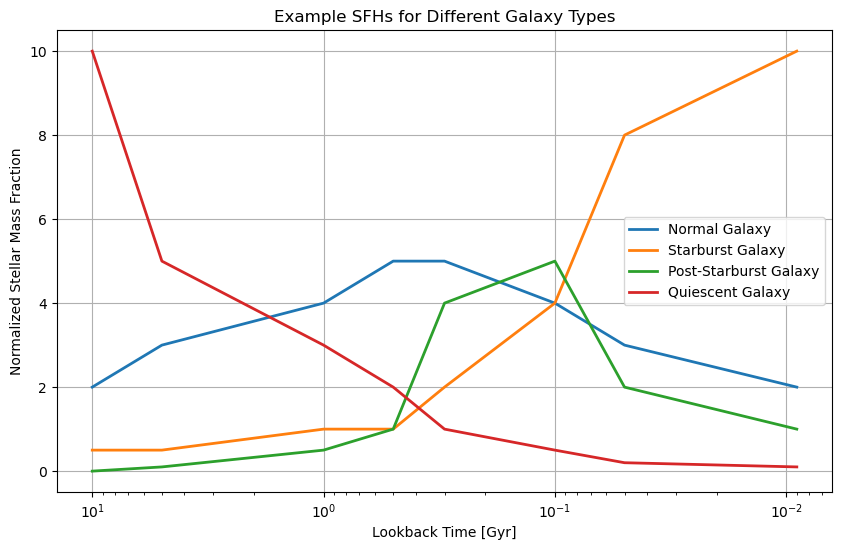

In [6]:
plt.figure(figsize=(10,6))

plt.plot(time_bins_gyr, sfh_normal_n, label="Normal Galaxy", linewidth=2)  #where='mid'
plt.plot(time_bins_gyr, sfh_starburst_n, label="Starburst Galaxy", linewidth=2)
plt.plot(time_bins_gyr, sfh_poststarburst_n, label="Post-Starburst Galaxy", linewidth=2)
plt.plot(time_bins_gyr, sfh_quiescent_n, label="Quiescent Galaxy", linewidth=2)

plt.gca().invert_xaxis()  # Lookback time: left = now, right = past
plt.xlabel("Lookback Time [Gyr]")
plt.ylabel("Normalized Stellar Mass Fraction")
plt.title("Example SFHs for Different Galaxy Types")
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [37]:

spectra = []
for sfh_weights,name in zip([sfh_normal,sfh_starburst,sfh_poststarburst,sfh_quiescent],['normal','starburst','poststarburst','quiescent']):

    sp = npfitter.synthetic_spectrum(
            time_bins=time_bins,
            sfh_weights=sfh_weights,
            fesc=0,
            ion_gas=-2,
            age_gas=5,
            av=0.1,
            av_ext=0.0,
            alpha=2,
            m_star=9.3,                           # log
            redshift=0.027,
            luminosity_distance=100,              # Mpc
            vel_sys=0.001,                        # systemic velocity [km/s]
            sigma_vel=150,                        # LOS velocity dispersion [km/s]
        multi_component=True,
    )

    sp.header['sfh type'] = name

    spectra.append(sp)


Line Ha EW: -14.18 Å
Line [N II] 6548 EW: 0.04 Å
Line [N II] 6583 EW: -0.15 Å
Line Ha EW: -203.48 Å
Line [N II] 6548 EW: -0.23 Å
Line [N II] 6583 EW: -1.03 Å
Line Ha EW: -41.59 Å
Line [N II] 6548 EW: 0.01 Å
Line [N II] 6583 EW: -0.05 Å
Line Ha EW: 1.46 Å
Line [N II] 6548 EW: 0.06 Å
Line [N II] 6583 EW: -0.02 Å
Line Hb EW: -1.00 Å
Line Hb EW: -34.48 Å
Line Hb EW: -5.38 Å
Line Hb EW: 2.03 Å
Line Hd EW: 1.96 Å
Line Hd EW: -4.63 Å
Line Hd EW: 0.52 Å
Line Hd EW: 2.75 Å


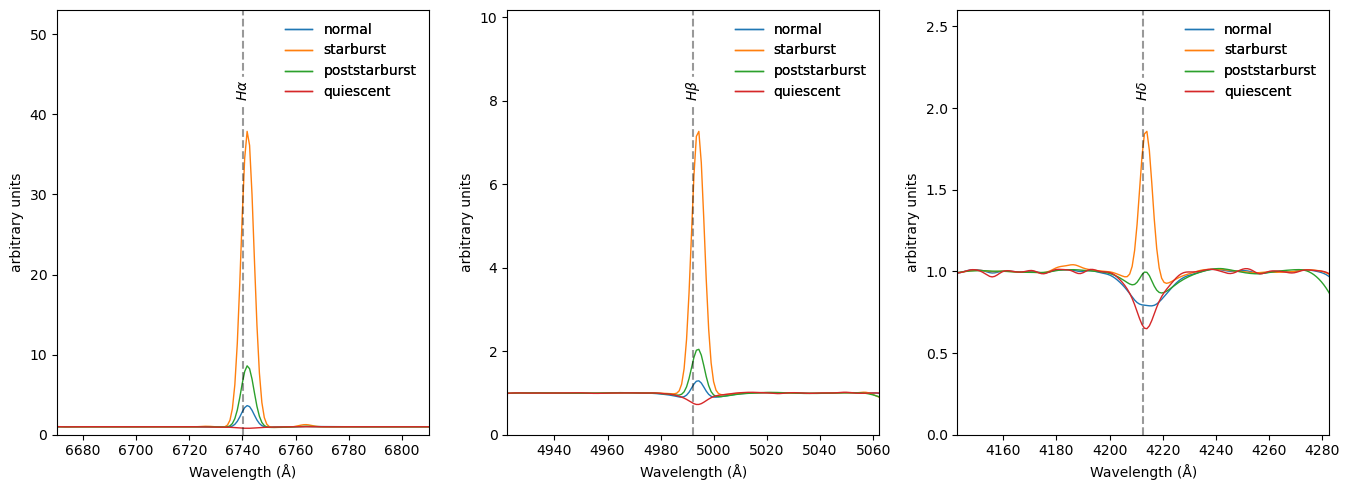

In [42]:
Spectrum().plot(spectra=spectra,
        show_top_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 1000,
        wsup=5e6,
        
        zoom_on_line=['Ha','Hb','Hd'],
        equivalent_widths=True,
        #remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(16,5),
        #redshift=0,
        #ymin=1e30,
        spec_legend_pars='sfh type',
        spec_legend_loc='upper right',
        ymin=1e-14
)


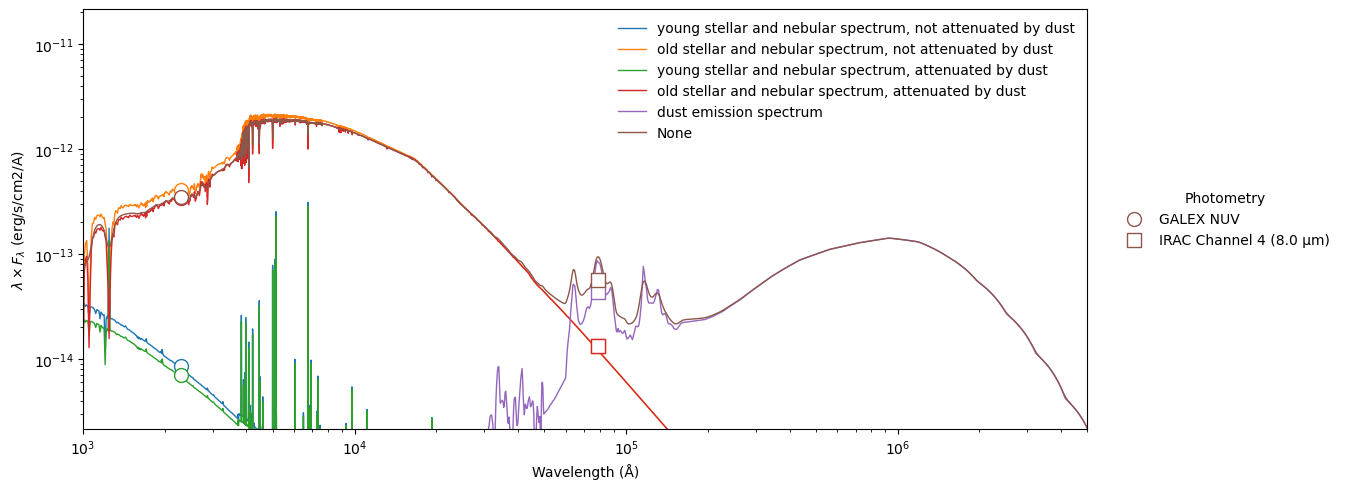

In [39]:
sp = spectra[3]
sp.plot(
        spectra=[sp.young_stellar_nebular,sp.old_stellar_nebular,sp.att_young_stellar_nebular,sp.att_old_stellar_nebular,sp.dust,sp],
        #show_top_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 1000,
        wsup=5e6,
        #remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(16,5),
        #redshift=0,
        #ymin=1e30,
        synth_phot=['galex_nuv','spitzer_irac_4'],
        spec_legend_pars='COMPONENT',
        spec_legend_loc='upper right',
        #ymin=1e-14
)


In [30]:
colors

array([[0.2298057 , 0.29871797, 0.75368315, 1.        ],
       [0.40442129, 0.53464349, 0.93200191, 1.        ],
       [0.60316207, 0.73152748, 0.99956528, 1.        ],
       [0.7867207 , 0.84480721, 0.93981038, 1.        ],
       [0.9306686 , 0.818877  , 0.75914639, 1.        ],
       [0.96731652, 0.65747083, 0.53816015, 1.        ],
       [0.88464344, 0.4100171 , 0.32250655, 1.        ],
       [0.70567316, 0.01555616, 0.15023281, 1.        ]])

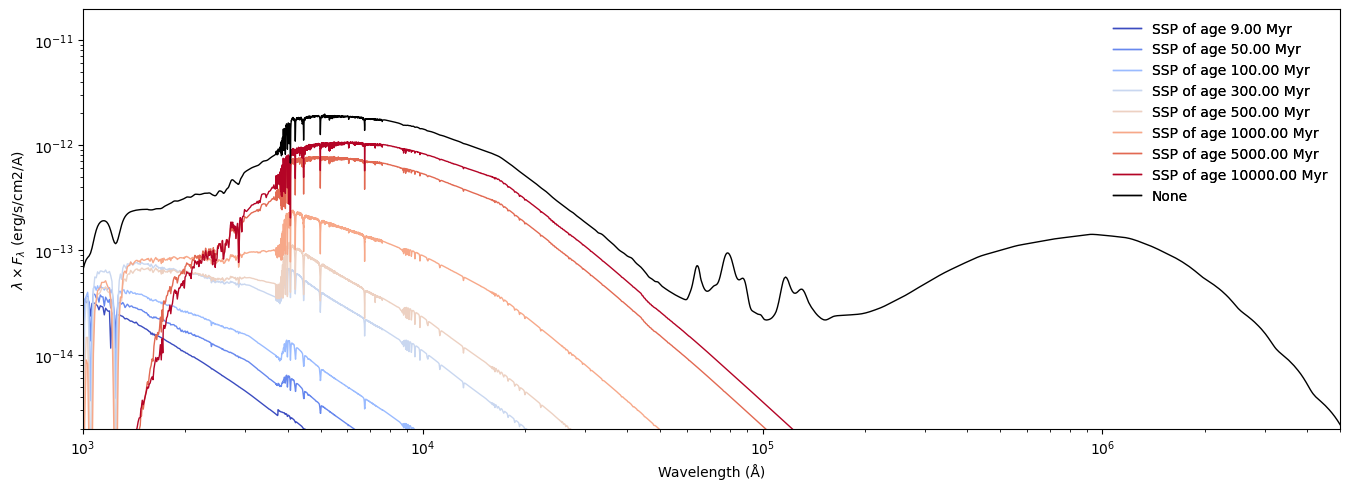

In [40]:
sp = spectra[3]
ssps_components = [sp.ssp_components[i] for i in range(len(sp.ssp_components))]

import matplotlib.cm as cm
cmap = cm.get_cmap("coolwarm")
colors = list(cmap(np.linspace(0, 1, len(ssps_components))))+ ['black']


sp.plot(
        spectra=ssps_components+[sp],
        #show_top_spectral_lines=True,
        show_atmospheric_lines=False,   
        per_wavelength=True,
        winf = 1000,
        wsup=5e6,
        #remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(16,5),
        #redshift=0,
        #ymin=1e30,
        spec_legend_pars='COMPONENT',
        spec_legend_loc='upper right',
        color=colors,
        #ymin=1e-14
)


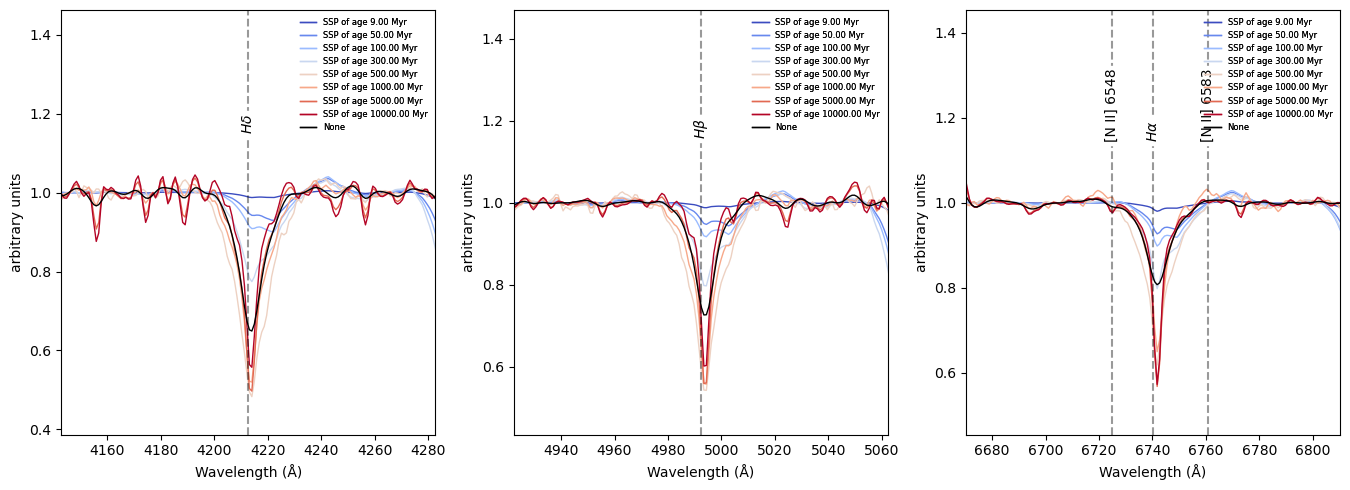

In [41]:
sp.plot(
        spectra=ssps_components+[sp],
        zoom_on_line=['Hd','Hb','Ha'],
        show_all_spectral_lines=True,   
        per_wavelength=False,
        winf = 1000,
        wsup=5e6,
        remove_continuum=True,
        #color=['red','cyan','green'],
        figsize=(16,5),
        #redshift=0,
        #ymin=1e30,
        spec_legend_pars='COMPONENT',
        spec_legend_loc='upper right',
        spec_legend_fontsize=6,
        color=colors,
)


In [37]:

sp = npfitter.synthetic_spectrum(
        time_bins=[10, 50, 100, 300, 500, 1000, 5000, 13000],
        sfh_weights=[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
        fesc=0.5,
        ion_gas=-3,
        age_gas=1.5,
        av=0.1,
        av_ext=0.0,
        alpha=2,
        m_star=9.3,                           # log
        redshift=0.027,
        luminosity_distance=100,              # Mpc
        vel_sys=0.0001,                         # systemic velocity [km/s]
        sigma_vel=200,                       # LOS velocity dispersion [km/s]
)


Line Ha EW: 2.30 Å
Line [N II] 6548 EW: 0.16 Å
Line [N II] 6583 EW: 0.15 Å
Line Hb EW: 2.98 Å
Line Hd EW: 3.69 Å


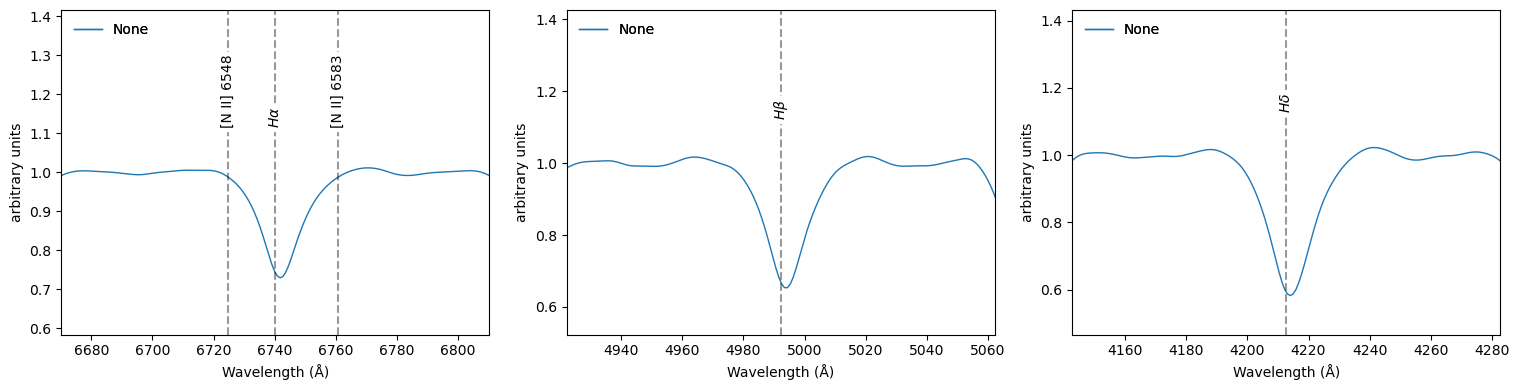

In [38]:
sp.plot(
    per_wavelength=False,
    winf=4800,wsup=5100, 
    zoom_on_line=['Ha','Hb','Hd'],
    equivalent_widths=True,
    ew_window=5,
    #remove_continuum=True,
    #ymin=5e-13, ymax= 1.5e-11, 
    #y_units='mJy',
    show_all_spectral_lines=True,
    show_atmospheric_lines=False,
    show_spec_legend=True,
    spec_legend_pars='sfh type',
)

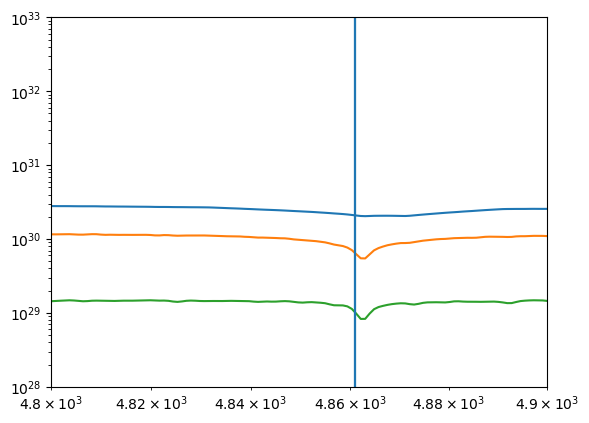

In [39]:

for age in [100,1000,13000]:
    ssp = npfitter.get_SSP(age)

    plt.plot(npfitter.model_wl,ssp)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(1e3,1e4)
    plt.ylim(1e28,1e33)
    plt.axvline(x=4861)
    plt.xlim(4800,4900)
